# Gradient Pattern Analysis (GPA) Applied to 2D Light Curves

**Authors:**  
Carlos Eduardo Falandes  
Mariana Rubet  

**Affiliations:**  
National Institute for Space Research (INPE)  
National Observatory (ON)  

---

## Overview

This notebook applies the **Gradient Pattern Analysis (GPA)** method to characterize structural patterns in astronomical light curves.

The analysis uses **2D representations of light curves**, where the temporal evolution of the observed signal is transformed into a two-dimensional matrix. The GPA method is then applied to analyze the organization of the resulting gradient field.

---

## Gradient Pattern Analysis

This notebook focuses on the computation of the **second gradient moment (G2)** from the Gradient Pattern Analysis framework.

The G2 moment measures the angular organization and alignment of gradient vectors, providing information about the structural complexity and asymmetry of the analyzed pattern.

The GPA calculations are performed using the implementation available in this repository.

---

## Dataset

The available 2D light curve datasets are located at:

```
../../data/light_curves/2d/
```

Available datasets:

- `SN_Ia.txt` — Type Ia Supernova
- `SN_II.txt` — Type II Supernova
- `TDE.txt` — Tidal Disruption Event
- `AGN.txt` — Active Galactic Nucleus

In this notebook, we analyze the **SN Ia light curve**.

---

## Results

The following section presents the results obtained from the application of the GPA method to the 2D light curve representation.

The results correspond to the **second gradient moment (G2)** calculated from the gradient field.

## Environment

This notebook was executed using the **Conda environment** defined in:

```
../gpa_env.yml
```

To create and activate the environment, run:

```bash
conda env create -f ../gpa_env.yml
conda activate gpa_env
```

After activating the environment, the notebook can be executed with:

```bash
jupyter notebook
```

or

```bash
jupyter lab
```

The environment contains all required dependencies for the **Gradient Pattern Analysis (GPA)** implementation and the analysis of 2D light curve datasets.

In [1]:
import sys
sys.path.append("../src")

from gpa.gpa import GPA
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_matrix(filename):
    """
    Load a square matrix from a text file.

    Parameters
    ----------
    filename : str
        Path to the text file containing the matrix values.

    Returns
    -------
    np.ndarray
        A square matrix reconstructed from the file values.

    Raises
    ------
    ValueError
        If the number of values in the file does not form a square matrix.
    """

    # Read all values from the file
    values = np.loadtxt(filename).flatten()

    # Determine the matrix size
    n = int(np.sqrt(len(values)))

    if n * n != len(values):
        raise ValueError(
            f"The file contains {len(values)} values, which cannot form a square matrix."
        )

    return values.reshape((n, n))


# Example
SN_Ia = load_matrix("../../data/light_curves/2d/SN_Ia.txt")
SN_II = load_matrix("../../data/light_curves/2d/SN_II.txt")
TDE = load_matrix("../../data/light_curves/2d/TDE.txt")
AGN = load_matrix("../../data/light_curves/2d/AGN.txt")

Text(0.5, 1.0, 'AGN matrix')

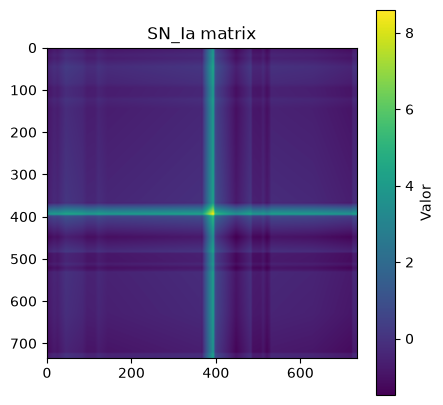

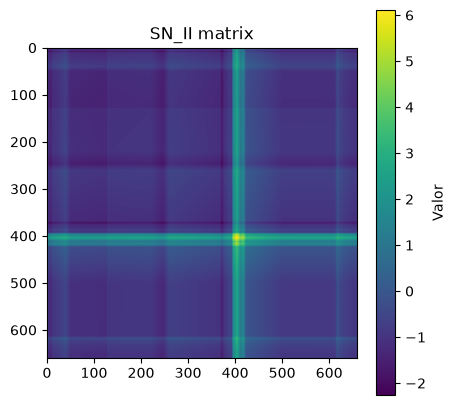

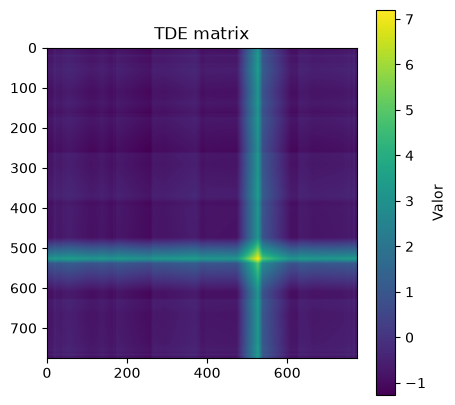

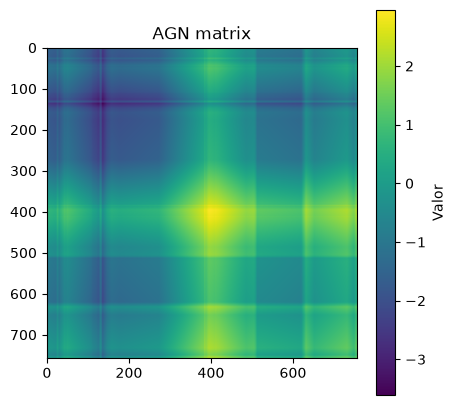

In [3]:
plt.figure(figsize=(5, 5))
plt.imshow(SN_Ia, cmap="viridis", origin="upper")
plt.colorbar(label="Valor")
plt.title("SN_Ia matrix")

plt.figure(figsize=(5, 5))
plt.imshow(SN_II, cmap="viridis", origin="upper")
plt.colorbar(label="Valor")
plt.title("SN_II matrix")

plt.figure(figsize=(5, 5))
plt.imshow(TDE, cmap="viridis", origin="upper")
plt.colorbar(label="Valor")
plt.title("TDE matrix")

plt.figure(figsize=(5, 5))
plt.imshow(AGN, cmap="viridis", origin="upper")
plt.colorbar(label="Valor")
plt.title("AGN matrix")

In [4]:
matrices = {
    "SN Ia": SN_Ia,
    "SN II": SN_II,
    "TDE": TDE,
    "AGN": AGN,
}

results = {}

for name, matrix in matrices.items():
    gpaObject = GPA(matrix)
    gpaObject.setPosition(len(matrix)//2, len(matrix)//2)

    ga = gpaObject.evaluate(
        mtol=0.019999999552965164,
        ftol=0.029999999329447746,
        ptol=0.009999999776482582,
    )

    results[name] = ga

for name, ga in results.items():
    print(f"{name}: {ga}")

SN Ia: {'G1': None, 'G2': np.float32(0.40557647), 'G3': None, 'G4': None}
SN II: {'G1': None, 'G2': np.float32(0.29279685), 'G3': None, 'G4': None}
TDE: {'G1': None, 'G2': np.float32(0.9239167), 'G3': None, 'G4': None}
AGN: {'G1': None, 'G2': np.float32(1.1529634), 'G3': None, 'G4': None}


In [5]:
results_center = {}

for name, matrix in matrices.items():
    gpaObject = GPA(matrix)

    # Here, I use the brightest pixel as the reference point.
    y, x = np.unravel_index(np.argmax(matrix), matrix.shape)
    gpaObject.setPosition(x, y)

    ga = gpaObject.evaluate(
        mtol=0.019999999552965164,
        ftol=0.029999999329447746,
        ptol=0.009999999776482582,
    )

    results_center[name] = ga

for name, ga in results_center.items():
    print(f"{name}: {ga}")

SN Ia: {'G1': None, 'G2': np.float32(0.3740102), 'G3': None, 'G4': None}
SN II: {'G1': None, 'G2': np.float32(0.34948722), 'G3': None, 'G4': None}
TDE: {'G1': None, 'G2': np.float32(0.93776673), 'G3': None, 'G4': None}
AGN: {'G1': None, 'G2': np.float32(1.1275221), 'G3': None, 'G4': None}


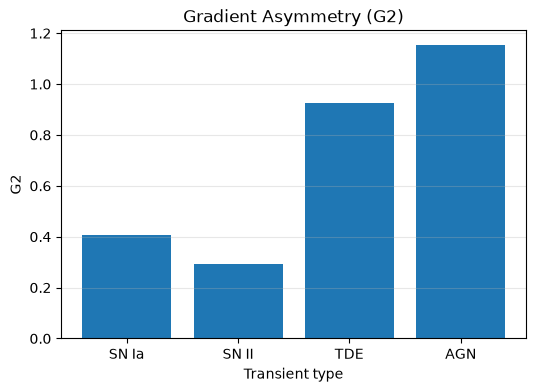

In [ ]:
names = list(results.keys())
values = [results[name]["G2"] for name in names]

plt.figure(figsize=(6,4))
plt.bar(names, values)

plt.ylabel("G2")
plt.xlabel("Transient type")
plt.title("Gradient Asymmetry (G2)")

plt.grid(axis="y", alpha=0.3)
plt.show()